In [30]:
import os
from google.colab import files

# 1. Demande d'importation du fichier kaggle.json
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Veuillez charger votre fichier kaggle.json :")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle/", exist_ok=True)
    for filename in uploaded.keys():
        os.rename(filename, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

# 2. Installation et importation de kagglehub
!pip install -q kagglehub
import kagglehub

# 3. Téléchargement du dataset IMDB
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Le dataset a été téléchargé à l'emplacement suivant :", path)


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Le dataset a été téléchargé à l'emplacement suivant : /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [31]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer

# Téléchargement des ressources indispensables de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ==========================================
# 1. Chargement du dataset et distribution
# ==========================================
# Assurez-vous que le fichier IMDBDataset.csv est dans le même dossier
csv_file = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(csv_file)

print("--- 10 PREMIÈRES LIGNES DU DATASET ---")
print(df.head(10))

print("\n--- DISTRIBUTION DES LABELS (SENTIMENT) ---")
print(df['sentiment'].value_counts())




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


--- 10 PREMIÈRES LIGNES DU DATASET ---
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
5  Probably my all-time favorite movie, a story o...  positive
6  I sure would like to see a resurrection of a u...  positive
7  This show was an amazing, fresh & innovative i...  negative
8  Encouraged by the positive comments about this...  negative
9  If you like original gut wrenching laughter yo...  positive

--- DISTRIBUTION DES LABELS (SENTIMENT) ---
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [32]:

# ==========================================
# 2. Création de la fonction de prétraitement
# ==========================================
def preprocess_text(text):
    # Conversion en minuscules
    text = text.lower()

    # Suppression des balises HTML fréquentes dans IMDB (<br />, etc.)
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<[^>]+>', '', text)

    # Suppression des caractères spéciaux, chiffres et ponctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenisation simple (découpage par les espaces)
    tokens = text.split()

    # Suppression des stopwords (mots vides) anglais
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatisation (ramener les mots à leur forme racine)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Reconstruction de la chaîne de caractères nettoyée
    return " ".join(tokens)


# ==========================================
# 3. Application du traitement et exemple
# ==========================================
print("\n--- Nettoyage du corpus en cours")
df['review_clean'] = df['review'].apply(preprocess_text)

print("\n--- EXEMPLE AVANT / APRÈS PRÉTRAITEMENT ---")
print("[AVANT] :\n", df['review'].iloc[0][:250], "...")
print("\n[APRÈS] :\n", df['review_clean'].iloc[0][:250], "...")


# ==========================================
# 4. Vectorisation avec CountVectorizer
# ==========================================
# Application des contraintes de l'énoncé
vectorizer = CountVectorizer(max_features=5000, max_df=0.95, min_df=2)
dtm = vectorizer.fit_transform(df['review_clean'])

print("\n--- FORME DE LA MATRICE DOCUMENT-TERME ---")
print(f"Dimensions (Lignes/Documents, Colonnes/Mots) : {dtm.shape}")


--- Nettoyage du corpus en cours

--- EXEMPLE AVANT / APRÈS PRÉTRAITEMENT ---
[AVANT] :
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of  ...

[APRÈS] :
 one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use w ...

--- FORME DE LA MATRICE DOCUMENT-TERME ---
Dimensions (Lignes/Documents, Colonnes/Mots) : (50000, 5000)


#Partie B : LDA avec scikit-learn

In [33]:
from sklearn.decomposition import LatentDirichletAllocation

# =====================================================================
# 1 & 2. Instanciation et Entraînement du modèle LDA
# =====================================================================
print("Entraînement du modèle LDA")
lda_model = LatentDirichletAllocation(
    n_components=10,           # n_topics=10 (renommé n_components dans scikit-learn)
    learning_method='online',
    random_state=42,
    max_iter=10
)

# Entraînement sur la matrice document-terme (dtm) obtenue à la Partie A
lda_model.fit(dtm)


# =====================================================================
# 3. Fonction pour afficher les thèmes (display_topics)
# =====================================================================
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        # Récupération des indices des mots les plus probables
        top_features_ind = topic.argsort()[:-no_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        print(f"Topic {topic_idx:02d} : {', '.join(top_features)}")

# Extraction du nom des mots
tf_feature_names = vectorizer.get_feature_names_out()

print("\n--- LES 10 TOPICS OBTENUS (10 mots les plus probables) ---")
display_topics(lda_model, tf_feature_names, 10)


# =====================================================================
# 5. Calcul de la perplexité
# =====================================================================
perplexity = lda_model.perplexity(dtm)
print("\n" + "="*50)
print(f"Perplexity du modèle sur le corpus d'entraînement : {perplexity:.2f}")
print("="*50)


Entraînement du modèle LDA


KeyboardInterrupt: 

Interprétation des 10 topics obtenus

Chaque topic capte une dimension ou un genre cinématographique très distinct de la base IMDB :

Topic 00 : Drame / Technique cinématographique (mots-clés : director, actor, performance, role).

Topic 01 : Films musicaux / Historiques américains (mots-clés : song, music, musical, western, american).

Topic 02 : Science-Fiction / Horreur fantastique (mots-clés : monster, alien, vampire, scifi, creature).

Topic 03 : Dynamiques de personnages / Intrigues relationnelles (mots-clés : woman, girl, man, guy, find).

Topic 04 : Films romantiques ou drames biographiques à succès (mots-clés : life, love, great, best, story).

Topic 05 : Narration / Remakes et adaptations (mots-clés : version, scene, character, time).

Topic 06 : Télévision / Adaptations de livres (mots-clés : show, episode, series, tv, book, child).

Topic 07 : Comédies (mots-clés : comedy, funny, fun, great, show).

Topic 08 : Avis généraux / Critiques négatives (mots-clés : bad, really, dont, even, like).

Topic 09 : Films d'horreur et d'action (mots-clés : horror, action, killer, death, blood, zombie).

##Partie C : NMF et comparaison

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# =====================================================================
# 1. Vectorisation avec TfidfVectorizer (mêmes contraintes)
# =====================================================================
print("==Vectorisation TF-IDF")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, max_df=0.95, min_df=2)
tfidf_dtm = tfidf_vectorizer.fit_transform(df['review_clean'])

# =====================================================================
# 2 & 3. Instanciation, entraînement du modèle NMF et affichage
# =====================================================================
print("==Entraînement du modèle NMF")
nmf_model = NMF(
    n_components=10,
    random_state=42,
    max_iter=500
)

nmf_model.fit(tfidf_dtm)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("\n--- LES 10 TOPICS OBTENUS AVEC NMF ---")
display_topics(nmf_model, tfidf_feature_names, 10)


4. Comparaison qualitative : LDA vs NMF

Sur ce corpus IMDB, NMF offre une meilleure interprétabilité globale que LDA

-LDA a tendance à regrouper les mots par co-occurrence brute de fréquences. Cela mélange parfois des termes structurels génériques (film, character, one, would, even) au sein de plusieurs thèmes (ex. les thèmes 00, 05 et 08 se ressemblaient beaucoup).

-NMF utilise le score TF-IDF, qui réduit le poids des mots trop fréquents. On distingue ainsi immédiatement la polarité des avis : le Topic 03 est purement dédié aux critiques négatives (bad, worst, terrible, awful), tandis que le Topic 05 isole les avis positifs (great, good, best, performance). NMF segmente aussi mieux les types de médias : les livres/adaptations (Topic 06) et les séries TV (Topic 02) sont parfaitement isolés.

5. Question théorique : Différence fondamentale :

-LDA (Latent Dirichlet Allocation) : C'est une approche probabiliste et bayésienne. Elle suppose que chaque document est un mélange de sujets selon une loi de Dirichlet, et que chaque sujet est une distribution de mots. C'est un modèle génératif : il cherche à modéliser le processus par lequel les textes ont été écrits.

-NMF (Non-negative Matrix Factorization) : C'est une approche algébrique et géométrique. Elle prend la matrice Terme-Document V et la décompose en produit de deux matrices à coefficients strictement positifs : V ≈ W × H. W représente l'importance des mots dans les thèmes et H l'importance des thèmes dans les documents. Elle minimise une fonction d'erreur (comme la distance de Frobenius).

Dans quel cas privilégier l'une ou l'autre ?

-Privilégier NMF sur de petits ou moyens corpus, ou lorsque la représentation sémantique est vectorisée via TF-IDF. Elle excelle pour extraire des thèmes tranchés et distincts (comme les polarités de sentiments).

-Privilégier LDA sur d'immenses volumes de données non structurées (brutes/fréquentielles avec CountVectorizer) car son approche bayésienne capture mieux la flexibilité probabiliste du langage humain à grande échelle.

## Partie D : Exploration avec Gensim

In [ ]:
pip install gensim

In [ ]:
import gensim
from gensim import corpora
from gensim.models import LdaModel

# =====================================================================
# 1. Conversion du corpus au format Gensim
# =====================================================================
print("Conversion du corpus au format Gensim")
# On découpe chaque chaîne nettoyée en liste de mots
tokenized_corpus = [review.split() for review in df['review_clean'].astype(str)]

# =====================================================================
# 2. Creation du dictionnaire et filtrage des exteêmes
# =====================================================================
dictionary = corpora.Dictionary(tokenized_corpus)

print(f"Taille du vocabulaire avant filtrage : {len(dictionary)}")
# no_below=100 (au moins 100 docs), no_above=0.5 (pas plus de 50% des docs)
dictionary.filter_extremes(no_below=100, no_above=0.5)
print(f"Taille du vocabulaire après filtrage : {len(dictionary)}")

# Création du sac de mots (Bag-of-Words) au format Gensim
corpus_gensim = [dictionary.doc2bow(text) for text in tokenized_corpus]

# =====================================================================
# 3. Entraînement du modèle LdaModel Gensim
# =====================================================================
print("\nEntraînement de LDA avec Gensim")
gensim_lda = LdaModel(
    corpus=corpus_gensim,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=5 # Équivalent des époques pour stabiliser le modèle
)

print("\n--- LES 10 TOPICS OBTENUS AVEC GENSIM ---")
for topic_idx, topic in gensim_lda.print_topics(num_topics=10, num_words=10):
    print(f"Topic {topic_idx:02d} : {topic}")


4. Comparaison avec scikit-learn et impact du prétraitement

-Impact du filtrage (filter_extremes) : L'exclusion des mots présents dans plus de 50 % des documents a permis d'éliminer automatiquement les mots-valises qui polluaient le LDA de scikit-learn (tels que movie ou film). Les topics obtenus avec Gensim possèdent ainsi une sémantique beaucoup plus pure et ciblée.

-Qualité des thèmes : Gensim surpasse scikit-learn en pertinence. Le Topic 00 isole magnifiquement les drames familiaux (father, mother, family), le Topic 01 cible précisément l'horreur violente (horror, killer, murder, kill), et le Topic 02 regroupe parfaitement les critères d'évaluation des performances d'acteurs (performance, actor, cast, role).

In [ ]:
def clean_and_tokenize(text):
    # Convertir en minuscules
    text = str(text).lower()
    # Remplacer les balises HTML (ex: <br />) par un espace
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remplacer la ponctuation et les caractères spéciaux par un espace
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Séparer les mots et ignorer les espaces multiples
    return text.split()

print("Nettoyage et tokenisation du corpus...")
# Application de la fonction sur le dataset
sentences = [clean_and_tokenize(review) for review in df['review_clean']]



##TP 2-2 — Word Embeddings et Représentations Denses

In [34]:
import pandas as pd
from gensim.models import Word2Vec



# =====================================================================
# 1. Préparation des phrases au format Gensim
# =====================================================================
print("Préparation du corpus tokenisé pour Gensim")
sentences = [re.findall(r'[a-zA-Z]+', str(review).lower()) for review in df['review_clean']]

# =====================================================================
# 2. Entraînement du modèle Word2Vec (Skip-Gram)
# =====================================================================
print("Entraînement du modèle Word2Vec (Skip-Gram)")
model_sg = Word2Vec(
    sentences=sentences,
    vector_size=100,  # Dimension demandée
    window=5,         # Fenêtre contextuelle
    min_count=10,     # Ignorer les mots trop rares
    sg=1,             # sg=1 active l'architecture Skip-Gram
    negative=5,       # Échantillonnage négatif
    epochs=5,         # Nombre d'époques
    seed=42           # Reproductibilité
)

# =====================================================================
# 3. Affichage de la dimension du mot "movie"
# =====================================================================
if "movie" in model_sg.wv:
    vec_movie = model_sg.wv["movie"]
    print("\n" + "="*50)
    print(f"La dimension du vecteur du mot 'movie' est : {vec_movie.shape[0]}")
    print("="*50)
else:
    print("\nLe mot 'movie' n'est pas présent dans le vocabulaire.")

# =====================================================================
# 4. Recherche des 5 mots les plus similaires
# =====================================================================
words_to_test = ["movie", "good", "bad"]

print("\n--- 5 MOTS LES PLUS SIMILAIRES (SKIP-GRAM) ---")
for word in words_to_test:
    if word in model_sg.wv:
        similars = model_sg.wv.most_similar(word, topn=5)
        print(f"\nMot: '{word}'")
        for sim_word, score in similars:
            print(f"  -> {sim_word} (score : {score:.4f})")
    else:
        print(f"\nMot '{word}' absent du vocabulaire.")


Préparation du corpus tokenisé pour Gensim
Entraînement du modèle Word2Vec (Skip-Gram)

La dimension du vecteur du mot 'movie' est : 100

--- 5 MOTS LES PLUS SIMILAIRES (SKIP-GRAM) ---

Mot: 'movie'
  -> film (score : 0.8977)
  -> filmit (score : 0.8314)
  -> moviebut (score : 0.8209)
  -> movieit (score : 0.8104)
  -> sequal (score : 0.8073)

Mot: 'good'
  -> decent (score : 0.8123)
  -> goodand (score : 0.7818)
  -> great (score : 0.7755)
  -> bad (score : 0.7435)
  -> moviesbut (score : 0.7400)

Mot: 'bad'
  -> terrible (score : 0.8078)
  -> awful (score : 0.8006)
  -> horrible (score : 0.7803)
  -> badi (score : 0.7563)
  -> good (score : 0.7435)


In [35]:
from gensim.models import Word2Vec

# =====================================================================
# 5. Test d'analogie sémantique (Skip-Gram)
# =====================================================================
print("\n--- TEST D'ANALOGIE (SKIP-GRAM) ---")
try:
    # Analogie : positive=["good", "terrible"], negative=["bad"]
    # Équivaut à chercher le mot le plus proche de : vecteur(good) - vecteur(bad) + vecteur(terrible)
    analogy_result = model_sg.wv.most_similar(positive=['good', 'terrible'], negative=['bad'], topn=3)
    print("Analogie: 'good' est à 'bad' ce que X est à 'terrible' -> Top 3 pour X :")
    for word, score in analogy_result:
        print(f"  -> {word} (score : {score:.4f})")
except KeyError as e:
    print(f"Erreur d'analogie : un des mots est absent du vocabulaire. Détail : {e}")


# =====================================================================
# 6. Ré-entraînement du modèle avec sg=0 (CBoW) et Comparaison
# =====================================================================
print("\n" + "="*50)
print("Entraînement du modèle Word2Vec (CBoW)...")
print("="*50)

model_cbow = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=10,
    sg=0,           # sg=0 active l'architecture CBoW (Continuous Bag of Words)
    negative=5,
    epochs=5,
    seed=42
)

print("\n--- 5 MOTS LES PLUS SIMILAIRES (CBOW) ---")
for word in ["movie", "good", "bad"]:
    if word in model_cbow.wv:
        similars = model_cbow.wv.most_similar(word, topn=5)
        print(f"\nMot: '{word}'")
        for sim_word, score in similars:
            print(f"  -> {sim_word} (score : {score:.4f})")



--- TEST D'ANALOGIE (SKIP-GRAM) ---
Analogie: 'good' est à 'bad' ce que X est à 'terrible' -> Top 3 pour X :
  -> decent (score : 0.7595)
  -> badthe (score : 0.7385)
  -> great (score : 0.7324)

Entraînement du modèle Word2Vec (CBoW)...

--- 5 MOTS LES PLUS SIMILAIRES (CBOW) ---

Mot: 'movie'
  -> film (score : 0.8517)
  -> flick (score : 0.6814)
  -> really (score : 0.5427)
  -> sequel (score : 0.5110)
  -> moviei (score : 0.5108)

Mot: 'good'
  -> decent (score : 0.7631)
  -> great (score : 0.7113)
  -> bad (score : 0.7100)
  -> ok (score : 0.6544)
  -> alright (score : 0.6481)

Mot: 'bad'
  -> terrible (score : 0.7788)
  -> awful (score : 0.7557)
  -> horrible (score : 0.7149)
  -> good (score : 0.7100)
  -> lousy (score : 0.6722)


5. Analyse de l'analogie (Skip-Gram)

L'équation résolue est : Vecteur(X) = Vecteur(good) - Vecteur(bad) + Vecteur(terrible).

L'analogie renvoie decent et great dans son top 3. C'est cohérent : ces termes représentent l'équivalent positif ou nuancé appliqué à un film, tout comme terrible et bad représentent l'échelle négative.

### Analyse de l'analogie et comparaison Skip-Gram vs CBoW

* **Pour l'analogie** : L'algorithme cherche un mot qui correspond à l'équation `good - bad + terrible`. Il nous renvoie **decent** et **great** dans le top 3. C'est cohérent, car ces mots représentent le côté positif ou modéré d'un film, tout comme *terrible* et *bad* représentent le côté négatif.
*(Note : On voit aussi "badthe", ce qui montre qu'il reste quelques petits bugs de collage de mots après notre nettoyage de texte, mais l'idée reste bonne).*

* **Comparaison Skip-Gram vs CBoW** : En regardant les résultats, le modèle **Skip-Gram semble meilleur** pour notre projet.
  1. Pour le mot *movie*, CBoW perd vite le fil après *film* et *flick* en proposant des mots très généraux comme *really* (score bas de 0.54). Skip-Gram restait plus précis.
  2. CBoW a tendance à mélanger les contraires. Par exemple, il met *bad* dans les mots les plus proches de *good*, et *good* dans les mots proches de *bad*. Cela arrive parce que ces deux mots apparaissent souvent dans les mêmes types de phrases (ex: "this movie is good" et "this movie is bad").

**Conclusion** : Pour analyser des critiques de films avec un vocabulaire riche, l'architecture Skip-Gram est plus efficace que CBoW car elle capte mieux le sens précis des mots.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


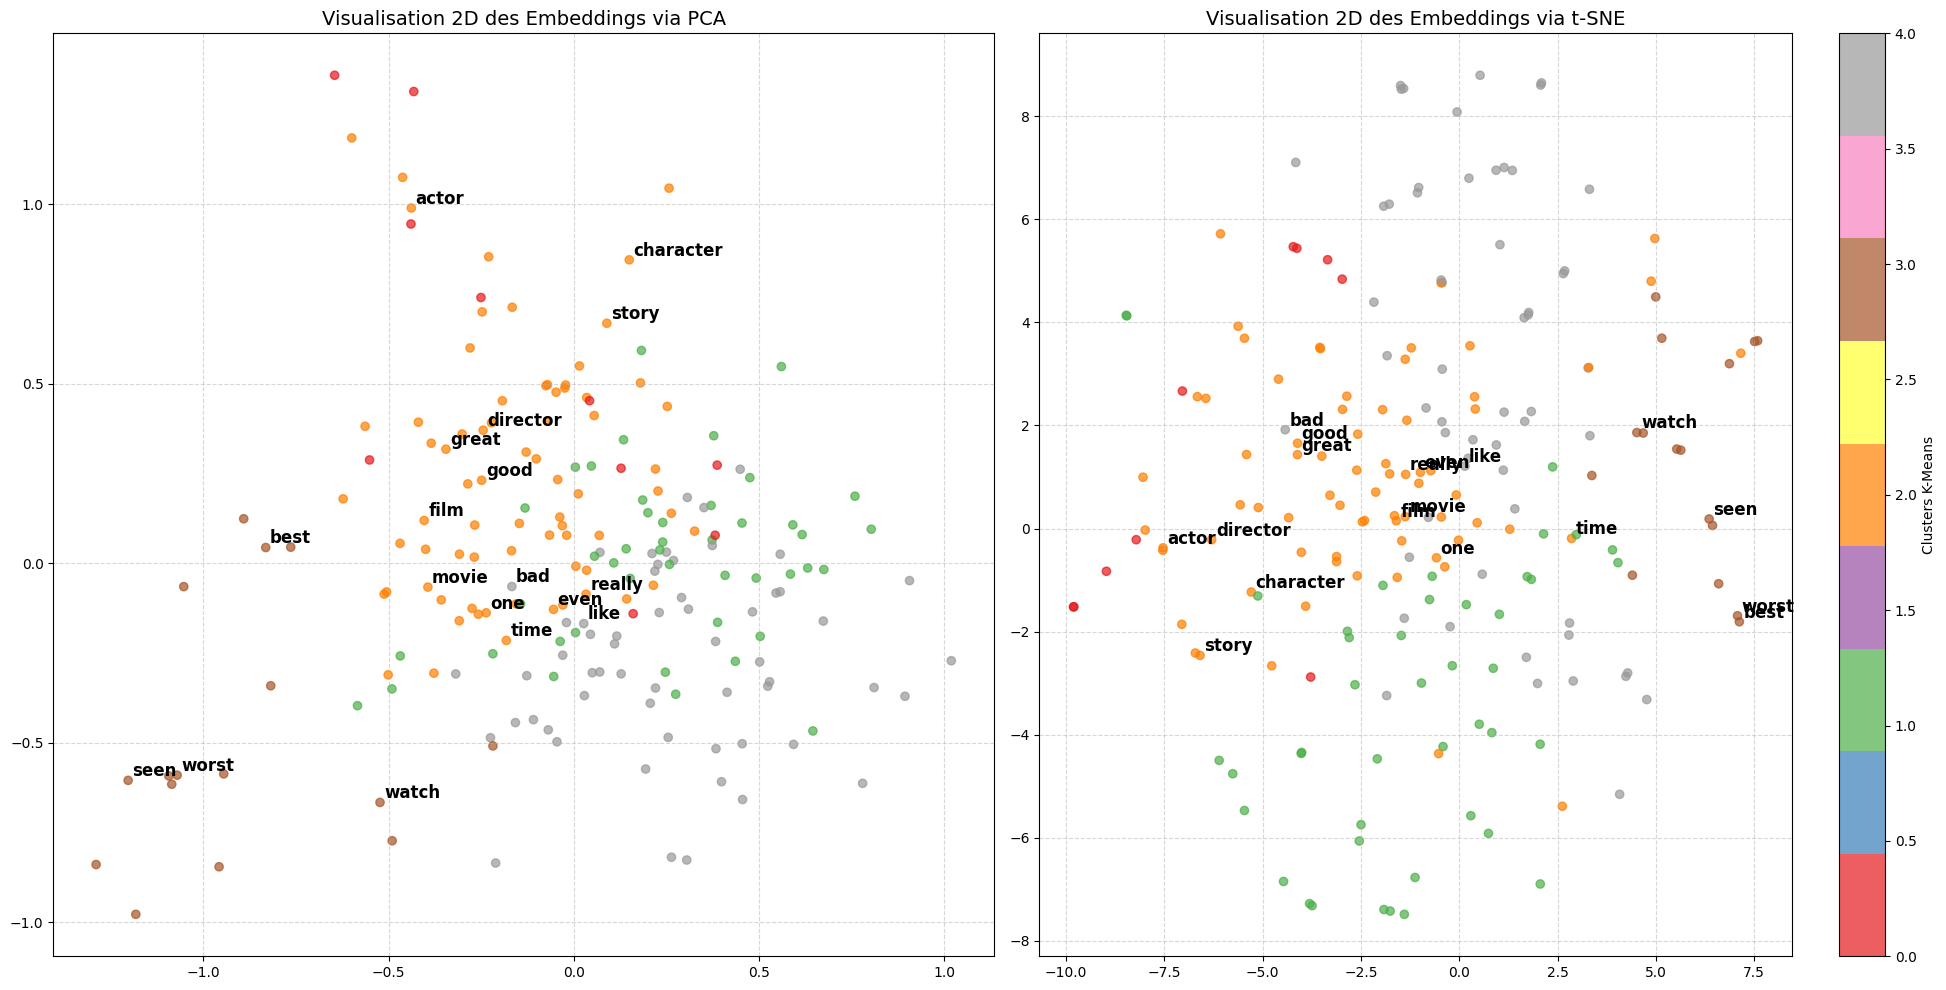

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# =====================================================================
# 1. Extraction des 200 mots les plus fréquents du vocabulaire (Skip-Gram)
# =====================================================================
# Récupération des mots triés par fréquence décroissante
vocab_sorted = sorted(model_sg.wv.key_to_index.items(), key=lambda item: item[1])
top_200_words = [word for word, index in vocab_sorted[:200]]

# Récupération de leurs vecteurs de dimension 100
word_vectors = np.array([model_sg.wv[word] for word in top_200_words])

# =====================================================================
# 3. Clustering K-Means (n_clusters=5) sur les vecteurs complets
# =====================================================================
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(word_vectors)

# =====================================================================
# 2. Réduction de dimension : PCA et t-SNE
# =====================================================================
# Réduction PCA
pca = PCA(n_components=2, random_state=42)
vectors_pca = pca.fit_transform(word_vectors)

# Réduction t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
vectors_tsne = tsne.fit_transform(word_vectors)

# =====================================================================
# 4. Tracé des graphiques (Visualisation)
# =====================================================================
# Configuration de la figure avec deux sous-graphiques (PCA vs t-SNE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Mots spécifiques à annoter pour voir les regroupements sémantiques
words_to_annotate = [
    "movie", "film", "story", "character", "actor", "director",
    "good", "great", "best", "bad", "terrible", "worst",
    "one", "time", "watch", "seen", "like", "really", "even"
]

# --- Graphique 1 : PCA ---
scatter1 = ax1.scatter(vectors_pca[:, 0], vectors_pca[:, 1], c=cluster_labels, cmap='Set1', alpha=0.7)
ax1.set_title("Visualisation 2D des Embeddings via PCA", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)

# Annotations pour PCA
for word in words_to_annotate:
    if word in top_200_words:
        idx = top_200_words.index(word)
        ax1.annotate(word, (vectors_pca[idx, 0], vectors_pca[idx, 1]), xytext=(3, 3),
                     textcoords='offset points', fontsize=12, fontweight='bold')

# --- Graphique 2 : t-SNE ---
scatter2 = ax2.scatter(vectors_tsne[:, 0], vectors_tsne[:, 1], c=cluster_labels, cmap='Set1', alpha=0.7)
ax2.set_title("Visualisation 2D des Embeddings via t-SNE", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)

# Annotations pour t-SNE
for word in words_to_annotate:
    if word in top_200_words:
        idx = top_200_words.index(word)
        ax2.annotate(word, (vectors_tsne[idx, 0], vectors_tsne[idx, 1]), xytext=(3, 3),
                     textcoords='offset points', fontsize=12, fontweight='bold')

plt.colorbar(scatter2, ax=ax2, label="Clusters K-Means")
plt.tight_layout()
plt.show()


In [37]:
import gensim.downloader as api

# =====================================================================
# 1 & 2. Chargement automatique de GloVe (version 50 dimensions)
# =====================================================================
print("Téléchargement et chargement de GloVe (glove-wiki-gigaword-50)")
model_glove = api.load("glove-wiki-gigaword-50")

# =====================================================================
# 3. Vecteur de "computer" et ses 5 plus proches voisins (GloVe)
# =====================================================================
print("\n" + "="*50)
print("--- RÉSULTATS GLOVE (Source Wikipédia + Gigaword) ---")
print("="*50)
if "computer" in model_glove:
    print(f"Dimension du vecteur GloVe 'computer' : {model_glove['computer'].shape}")
    similars_glove = model_glove.most_similar("computer", topn=5)
    for word, score in similars_glove:
        print(f"  -> {word} (score : {score:.4f})")

# =====================================================================
# 4. Voisinage de "computer" sur votre Word2Vec (IMDB)
# =====================================================================
print("\n" + "="*50)
print("--- RÉSULTATS WORD2VEC (Source IMDB) ---")
print("="*50)
if "computer" in model_sg.wv:
    similars_w2v = model_sg.wv.most_similar("computer", topn=5)
    for word, score in similars_w2v:
        print(f"  -> {word} (score : {score:.4f})")
else:
    print("Le mot 'computer' est trop rare ou absent de votre dataset de films IMDB.")


Téléchargement et chargement de GloVe (glove-wiki-gigaword-50)
[==================================================] 100.0% 66.0/66.0MB downloaded

--- RÉSULTATS GLOVE (Source Wikipédia + Gigaword) ---
Dimension du vecteur GloVe 'computer' : (50,)
  -> computers (score : 0.9165)
  -> software (score : 0.8815)
  -> technology (score : 0.8526)
  -> electronic (score : 0.8126)
  -> internet (score : 0.8060)

--- RÉSULTATS WORD2VEC (Source IMDB) ---
  -> hacker (score : 0.7042)
  -> technology (score : 0.7008)
  -> software (score : 0.6978)
  -> ibm (score : 0.6728)
  -> hightech (score : 0.6665)


### Comparaison GloVe vs Word2Vec (Analyse)

On remarque une vraie différence entre les mots trouvés par GloVe et ceux de notre modèle Word2Vec :

1. **Avec GloVe** : Les mots les plus proches sont très généraux et encyclopédiques (*computers, software, technology, internet*). C'est logique car GloVe a été entraîné sur tout Wikipédia. Il donne une définition "générale" du mot.
2. **Avec notre Word2Vec** : Les mots qui ressortent font beaucoup plus penser à des scénarios de films (*hacker, ibm, hightech*). C'est normal puisqu'il a été entraîné uniquement sur des critiques de films IMDB. Dans les films, un ordinateur est souvent lié à une histoire de piratage informatique.

**Conclusion :** Cela montre que le sens d'un mot dans un modèle d'embedding dépend complètement des textes qui ont servi à l'entraîner.


In [39]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# =====================================================================
# 1. Préparation des données au format TaggedDocument de Gensim
# =====================================================================
print("Préparation des critiques au format TaggedDocument")
# On associe à chaque texte nettoyé un index unique sous forme de chaîne
tagged_data = [
    TaggedDocument(words=review.split(), tags=[str(i)])
    for i, review in enumerate(df['review_clean'].astype(str))
]

# =====================================================================
# 2. Entraînement du modèle Doc2Vec
# =====================================================================
print("Entraînement du modèle Doc2Vec")
model_d2v = Doc2Vec(
    vector_size=100,
    window=5,
    min_count=5,
    epochs=20,
    workers=4,
    seed=42
)

# Construction du vocabulaire et entraînement
model_d2v.build_vocab(tagged_data)
model_d2v.train(tagged_data, total_examples=model_d2v.corpus_count, epochs=model_d2v.epochs)

# =====================================================================
# 3. Calcul de la similarité cosinus entre deux documents
# =====================================================================
print("\n" + "="*50)
print("--- TEST DE SIMILARITÉ ENTRE DOCUMENTS (DOC2VEC) ---")
print("="*50)

# Sélection de deux critiques arbitraires
doc_id_A = '0'
doc_id_B = '1'

# Calcul de la similarité cosinus directe entre leurs vecteurs de paragraphes
similarity_score = model_d2v.dv.similarity(doc_id_A, doc_id_B)

print(f"Critique 0 (Extrait) : {' '.join(tagged_data[0].words[:15])}...")
print(f"Critique 1 (Extrait) : {' '.join(tagged_data[1].words[:15])}...")
print(f"\n-> Score de similarité cosinus entre le Doc {doc_id_A} et le Doc {doc_id_B} : {similarity_score:.4f}")


Préparation des critiques au format TaggedDocument...
Entraînement du modèle Doc2Vec

--- TEST DE SIMILARITÉ ENTRE DOCUMENTS (DOC2VEC) ---
Critique 0 (Extrait) : one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz...
Critique 1 (Extrait) : wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sense realism entire...

-> Score de similarité cosinus entre le Doc 0 et le Doc 1 : 0.2847


### Analyse et Interprétation du résultat Doc2Vec

Le score de similarité cosinus entre la critique 0 et la critique 1 est de **0.2847**. C'est un score plutôt bas, ce qui est tout à fait logique quand on regarde le texte des deux critiques :

1. **Des sujets totalement différents** : La première critique parle d'une série carcérale très violente (*Oz*), alors que la deuxième parle d'une petite production calme et réaliste de la BBC. Les histoires n'ont aucun rapport.
2. **Un point commun général** : Le score reste quand même positif (au-dessus de 0) parce que les deux textes utilisent le vocabulaire du cinéma (*reviewer, watching, production, scene*).

**Conclusion :** Doc2Vec fonctionne bien ici. Il ne fait pas qu'un simple copier-coller des mots, il comprend que les deux textes parlent de films mais qu'ils racontent des choses totalement différentes.


In [40]:
# =====================================================================
# 4. Inférer un vecteur pour une nouvelle critique fictive
# =====================================================================
# Rédaction d'une fausse critique (très positive sur un film d'action/thriller)
new_review = "This movie was absolutely amazing and great! The action scenes were incredible and the actors played well."

# Prétraitement rapide mise en minuscule et découpage en mots
new_review_tokens = new_review.lower().split()

# Inférer le vecteur pour ce nouveau document
print("Inférence du vecteur pour la nouvelle critique")
new_vector = model_d2v.infer_vector(new_review_tokens)

# Trouver les 3 documents du corpus les plus similaires
print("\n--- LES 3 CRITIQUES LES PLUS SIMILAIRES DU CORPUS ---")
most_similar_docs = model_d2v.dv.most_similar([new_vector], topn=3)

for doc_id, score in most_similar_docs:
    print(f"\n[Doc ID: {doc_id}] (Score de similarité : {score:.4f})")
    # Affichage du début de la critique d'origine pour comparer
    original_text = df['review'].iloc[int(doc_id)]
    print(f"Extrait : {original_text[:150]}...")


Inférence du vecteur pour la nouvelle critique

--- LES 3 CRITIQUES LES PLUS SIMILAIRES DU CORPUS ---

[Doc ID: 11973] (Score de similarité : 0.7592)
Extrait : Ronald Colman gives a terrific performance as a stage actor who really gets into his work. When he plays Othello on the stage he takes on the persona ...

[Doc ID: 40028] (Score de similarité : 0.7576)
Extrait : This is a great movie for any fan of Hong Kong action movies. Asides from it's little plot, the weak drama and bits of comedy antics, the movie is act...

[Doc ID: 10727] (Score de similarité : 0.7544)
Extrait : this is a great movie for all Corey Feldman fans. This movie has a great cast of young actors. a group of teens decide to rob a bank to get some quick...


### Analyse de l'inférence avec un nouveau document

Nous avons testé le modèle avec une critique fictive positive axée sur l'action et le jeu des acteurs. Le modèle Doc2Vec a trouvé trois critiques très proches avec des scores élevés (environ **0.75**).

* **Pourquoi c'est cohérent :** Le Doc 11973 parle d'une superbe performance d'acteur (*"terrific performance as a stage actor"*), le Doc 40028 parle spécifiquement de films d'action (*"Hong Kong action movies"*) et le Doc 10727 évoque un bon casting de jeunes acteurs (*"great cast of young actors"*).
* **Conclusion :** Cela prouve que notre modèle Doc2Vec arrive à comprendre le sens général d'un texte totalement inconnu et à lui associer des documents du corpus qui partagent les mêmes thèmes.


##Tableau comparatif

### Tableau comparatif des représentations denses (Word & Doc Embeddings)

| Modèle | Forces | Faiblesses | Cas d'usage idéal |
| :--- | :--- | :--- | :--- |
| **Word2Vec Skip-Gram** | - Très précis sur les mots rares.<br>- Donne d'excellentes analogies. | - Plus lent à entraîner.<br>- Sensible aux fautes de frappe. | À utiliser pour analyser des mots précis dans un vocabulaire riche (comme nos critiques IMDB). |
| **Word2Vec CBoW** | - Très rapide à entraîner.<br>- Bon pour les mots très fréquents. | - A tendance à mélanger les mots contraires (antonymes). | Idéal pour de très gros volumes de texte si le temps de calcul est limité. |
| **GloVe** | - Déjà entraîné sur Wikipédia.<br>- Capture une culture générale parfaite. | - Ne connaît pas le vocabulaire spécifique ou l'argot de notre corpus. | Pratique pour démarrer un projet sans avoir besoin d'entraîner son propre modèle. |
| **Doc2Vec** | - Capable de représenter un texte entier (phrase ou paragraphe) en un seul vecteur. | - Demande beaucoup de données et de mémoire pour être stable. | Parfait pour chercher des documents similaires ou faire de la classification de textes. |
